In [ ]:
import os
import sys
import re
import numpy as np
import pandas as pd
import plotly.express as px
import scipy.stats as stats
from dash import html, dcc, Input, Output, Dash
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ast import literal_eval

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_validate
import seaborn as sns


sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))
from baseVR.base_functionality import init_import_paths
init_import_paths() 

from CustomLogger import CustomLogger as Logger
from analytics_processing import analytics

from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args, fullfnames2snames

In [2]:
Logger().init_logger(None, None, logging_level="DEBUG")
animal_ids = [6]
paradigm = [1100]
session_range = [1,33]
session_ids = None
normalize = True
smooth = False
excl_session_names = ['2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min', '2025-01-22_17-51_rYL006_P1100_LinearTrackStop_5min', '2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min']

session_dirs = sessionlist_fullfnames_from_args(paradigm, animal_ids, session_ids, excl_session_names=excl_session_names)[0]
session_names= fullfnames2snames(session_dirs)

2026-02-12 19:41:31,899|DEBUG|18471|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-02-12 19:41:33,289|DEBUG|18471|sessions_from_nas_parsing|get_sessionlist_fullfnames
	For paradigms [1100], animals [6], found 34 sessions.
2026-02-12 19:41:33,289|DEBUG|18471|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions



In [3]:
# firing rates and behavior data
fr = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
fr_track = analytics.get_analytics('FiringRateTrackwiseHz', session_names=session_names)
fr_z_scored  = analytics.get_analytics('FiringRate40msZ', session_names=session_names)
fr_z_all_sess = fr.apply(lambda unit_fr: ((unit_fr - unit_fr.mean()) / unit_fr.std()))
t0_events = analytics.get_analytics('TrialWiseT0Events40ms', session_names=session_names)
# behav = analytics.get_analytics('BehaviorTrackwise', session_names=session_names)
# behav.index = behav.index.droplevel(('animal_id', 'paradigm_id', 'entry_id'))

# ensamble related data
t0_ens = analytics.get_analytics('EnsembleT0Projection', session_names=session_names)
# ensambles = analytics.get_analytics('ConcatenatedEnsambles40ms', session_names=session_names)
# ens_data = analytics.get_analytics('TrackwiseEnsembleProj', session_names=session_names)
# ensamble_proj = analytics.get_analytics('ConcatenatedEnsambleProj40ms', session_names=session_names)#.drop("to_ephys_timestamp", axis=1)
# ensamble_proj.set_index(['session_id'], inplace = True)
# ens_data = ens_data.set_index(['session_id', 'trial_id']).sort_index()

2026-02-12 19:41:33,301|DEBUG|18471|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-02-12 19:41:33,622|DEBUG|18471|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-02-12 19:41:33,623|DEBUG|18471|analytics|get_analytics
	Processing FiringRate40msHz, (1100, 6, '2024-11-14_15-01') 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/Volumes/large/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2026-02-12 19:41:33,637|INFO|18471|analytics|get_analytics
	Analytic `FiringRate40msHz` does not exist for (1100, 6, '2024-11-14_15-01'), compute first, or check for typo
2026-02-12 19:41:33,639|DEBUG|18471|analytics|get_analytics
	Processing FiringRate40msHz, (1100, 6, '2024-11-14_16-40') 2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min.hdf5

In [12]:
t0_events

trial_id  cue  trial_outcome  \
paradigm_id animal_id session_id       entry_id                                 
1100        6         2024-11-14_16-40 0                1  1.0            0.0   
                                       1                1  1.0            0.0   
                                       2                1  1.0            0.0   
                                       3                1  1.0            0.0   
                                       4                1  1.0            0.0   
...                                                   ...  ...            ...   
                      2025-01-27_13-39 755            152  2.0            1.0   
                                       756            152  2.0            1.0   
                                       757            152  2.0            1.0   
                                       758            152  2.0            1.0   
                                       759            152  2.0            1.0   

                                                 choice_R1  choice_R2  \
paradigm_id animal_id session_id       entry_id                         
1100        6         2024-11-14_16-40 0             False      False   
                                       1             False      False   
                                       2             False      False   
                                       3             False      False   
                                       4             False      False   
...                                                    ...        ...   
                      2025-01-27_13-39 755           False       True   
                                       756           False       True   
                                       757           False       True   
                                       758           False       True   
                                       759           False       True   

                                                     t0_event_name  \
paradigm_id animal_id session_id       entry_id                      
1100        6         2024-11-14_16-40 0           cueZone_visible   
                                       1             cueZone_entry   
                                       2              cueZone_exit   
                                       3         enter_reward1Zone   
                                       4         enter_reward2Zone   
...                                                            ...   
                      2025-01-27_13-39 755         cueZone_visible   
                                       756           cueZone_entry   
                                       757            cueZone_exit   
                                       758       enter_reward1Zone   
                                       759       enter_reward2Zone   

                                                           t0  x_position  \
paradigm_id animal_id session_id       entry_id                             
1100        6         2024-11-14_16-40 0         4.600000e+06 -119.732063   
                                       1         5.400000e+06  -79.536247   
                                       2         6.760000e+06   24.898020   
                                       3         7.080000e+06   51.438919   
                                       4         9.480000e+06  170.376450   
...                                                       ...         ...   
                      2025-01-27_13-39 755       4.393240e+09 -120.656754   
                                       756       4.394000e+09  -79.428299   
                                       757       4.396000e+09   25.843262   
                                       758       4.396480e+09   49.770477   
                                       759       4.398880e+09  170.561493   

                                                 x_alignment  \
paradigm_id animal_id session_id       entry_id                
1100

In [ ]:
# Modeling imports + helper to convert Assembly012 into numeric vectors
def assembly_to_vector(x):
    """Convert Assembly012 entries (scalar/list/array/stringified list) to a 1D float vector."""
    if x is None:
        return None

    if isinstance(x, (float, np.floating)) and np.isnan(x):
        return None

    if isinstance(x, str):
        try:
            x = literal_eval(x)
        except Exception:
            try:
                return np.asarray([float(x)], dtype=float)
            except Exception:
                return None

    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(x, dtype=float).ravel()
    else:
        try:
            arr = np.asarray([float(x)], dtype=float)
        except Exception:
            return None

    if arr.size == 0 or not np.isfinite(arr).all():
        return None
    return arr


In [ ]:
# Build model-ready table from t0_ens
model_df = t0_ens.reset_index().copy()

required_cols = [
    "session_id",
    "trial_id",
    "interval_name",
    "cue",
    "choice_R1",
    "choice_R2",
    "Assembly012",
]
missing_cols = [c for c in required_cols if c not in model_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in t0_ens: {missing_cols}")

# Clean choice columns and keep only valid one-hot choices (R1 xor R2)
model_df["choice_R1"] = model_df["choice_R1"].astype("boolean")
model_df["choice_R2"] = model_df["choice_R2"].astype("boolean")

has_one_choice = (
    model_df["choice_R1"].notna()
    & model_df["choice_R2"].notna()
    & (model_df["choice_R1"].fillna(False) != model_df["choice_R2"].fillna(False))
)
model_df = model_df.loc[has_one_choice].copy()

# Targets:
# raw choice label (R1 vs R2)
model_df["target_choice_r1"] = model_df["choice_R1"].astype(int)

# correctness relative to cue (assumes cue==1 => R1 should be chosen)
model_df["target_correct_for_cue"] = np.where(
    model_df["cue"] == 1,
    model_df["choice_R1"].fillna(False),
    model_df["choice_R2"].fillna(False),
).astype(int)

# Feature vectors from Assembly012
model_df["x_vec"] = model_df["Assembly012"].apply(assembly_to_vector)
model_df = model_df[model_df["x_vec"].notna()].copy()

vec_len = model_df["x_vec"].map(len)
if vec_len.nunique() > 1:
    modal_len = int(vec_len.mode().iloc[0])
    model_df = model_df[vec_len == modal_len].copy()
    print(f"Assembly012 had mixed vector lengths; kept rows with modal length = {modal_len}")

print(f"Rows kept: {len(model_df)}")
print(f"Intervals: {model_df['interval_name'].nunique()} | Sessions: {model_df['session_id'].nunique()}")
print("Target balance (choice_R1):")
print(model_df["target_choice_r1"].value_counts(normalize=True).rename("fraction"))

model_df.head()


Rows kept: 185085
Intervals: 5 | Sessions: 28
Target balance (choice_R1):
target_choice_r1
0    0.591539
1    0.408461
Name: fraction, dtype: float64


,paradigm_id,animal_id,session_id,entry_id,from_ephys_timestamp,to_ephys_timestamp,Assembly001,Assembly002,Assembly003,Assembly004,...,choice_R1,choice_R2,t0_event_name,t0,x_position,x_alignment,interval_name,target_choice_r1,target_correct_for_cue,x_vec
10,1100,6,2024-11-14_16-40,10,24720000,24760000,0.725500,-0.287326,-0.275773,1.200532,...,True,False,cueZone_visible,24920000.0,-119.248932,-120.0,pre_cue_interval,1,0,[-0.28352014110328455]
11,1100,6,2024-11-14_16-40,11,24760000,24800000,0.094097,0.112882,-0.005106,-0.028851,...,True,False,cueZone_visible,24920000.0,-119.248932,-120.0,pre_cue_interval,1,0,[-0.10536072525051922]
12,1100,6,2024-11-14_16-40,12,24800000,24840000,-0.086904,-0.370677,-0.115366,-0.259508,...,True,False,cueZone_visible,24920000.0,-119.248932,-120.0,pre_cue_interval,1,0,[-0.13359828078887934]
13,1100,6,2024-11-14_16-40,13,24840000,24880000,-0.029783,0.129427,-0.061846,0.016860,...,True,False,cueZone_visible,24920000.0,-119.248932,-120.0,pre_cue_interval,1,0,[-0.13855215568221033]
14,1100,6,2024-11-14_16-40,14,24880000,24920000,0.279578,-0.104786,-0.137576,-0.197564,...,True,False,cueZone_visible,24920000.0,-119.248932,-120.0,pre_cue_interval,1,0,[-0.28320889368433794]


In [9]:
MODELS = {
    "LogReg": Pipeline(
        steps=[
            ("scale", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
}


def evaluate_intervals(df, target_col, min_samples=25):
    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1": "f1",
        "roc_auc": "roc_auc",
    }

    rows = []
    skipped = []

    for interval_name, g in df.groupby("interval_name", dropna=False):
        n = len(g)
        n_sessions = g["session_id"].nunique()
        y = g[target_col].astype(int).to_numpy()

        if n < min_samples:
            skipped.append(
                {
                    "interval_name": interval_name,
                    "reason": f"n<{min_samples}",
                    "n_samples": n,
                    "n_sessions": n_sessions,
                }
            )
            continue

        if np.unique(y).size < 2:
            skipped.append(
                {
                    "interval_name": interval_name,
                    "reason": "only one target class",
                    "n_samples": n,
                    "n_sessions": n_sessions,
                }
            )
            continue

        if n_sessions < 2:
            skipped.append(
                {
                    "interval_name": interval_name,
                    "reason": "fewer than 2 sessions",
                    "n_samples": n,
                    "n_sessions": n_sessions,
                }
            )
            continue

        X = np.vstack(g["x_vec"].to_numpy())
        groups = g["session_id"].to_numpy()
        cv = GroupKFold(n_splits=min(5, n_sessions))

        for model_name, estimator in MODELS.items():
            cv_scores = cross_validate(
                estimator,
                X,
                y,
                groups=groups,
                cv=cv,
                scoring=scoring,
                n_jobs=-1,
                error_score=np.nan,
                return_train_score=False,
            )

            rows.append(
                {
                    "target": target_col,
                    "interval_name": interval_name,
                    "model": model_name,
                    "n_samples": n,
                    "n_sessions": n_sessions,
                    "positive_rate": float(np.mean(y)),
                    "accuracy_mean": float(np.nanmean(cv_scores["test_accuracy"])),
                    "accuracy_std": float(np.nanstd(cv_scores["test_accuracy"])),
                    "balanced_accuracy_mean": float(np.nanmean(cv_scores["test_balanced_accuracy"])),
                    "balanced_accuracy_std": float(np.nanstd(cv_scores["test_balanced_accuracy"])),
                    "f1_mean": float(np.nanmean(cv_scores["test_f1"])),
                    "f1_std": float(np.nanstd(cv_scores["test_f1"])),
                    "roc_auc_mean": float(np.nanmean(cv_scores["test_roc_auc"])),
                    "roc_auc_std": float(np.nanstd(cv_scores["test_roc_auc"])),
                }
            )

    results = pd.DataFrame(rows)
    if not results.empty:
        results = results.sort_values(
            ["balanced_accuracy_mean", "accuracy_mean"],
            ascending=False,
        ).reset_index(drop=True)

    skipped = pd.DataFrame(skipped)
    return results, skipped


In [10]:
choice_results, choice_skipped = evaluate_intervals(
    model_df,
    target_col="target_choice_r1",
    min_samples=25,
)
correct_results, correct_skipped = evaluate_intervals(
    model_df,
    target_col="target_correct_for_cue",
    min_samples=25,
)

print("Choice prediction (target_choice_r1)")
display(choice_results)

print("\nCue-correctness prediction (target_correct_for_cue)")
display(correct_results)

if not choice_skipped.empty:
    print("\nIntervals skipped for choice target:")
    display(choice_skipped)

if not correct_skipped.empty:
    print("\nIntervals skipped for correctness target:")
    display(correct_skipped)


Choice prediction (target_choice_r1)


,target,interval_name,model,n_samples,n_sessions,positive_rate,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,target_choice_r1,R2_entry_interval,RandomForest,54840,28,0.408461,0.529544,0.022891,0.521851,0.005728,0.425873,0.045321,0.532783,0.007689
1,target_choice_r1,pre_cue_interval,RandomForest,6855,28,0.408461,0.518302,0.005146,0.511921,0.013706,0.414474,0.057696,0.510715,0.013149
2,target_choice_r1,nextto_cue_interval,RandomForest,6855,28,0.408461,0.519731,0.018178,0.511752,0.010195,0.416213,0.053267,0.523033,0.007992
3,target_choice_r1,R1_entry_interval,RandomForest,61695,28,0.408461,0.519066,0.020261,0.511234,0.004074,0.412037,0.041710,0.515207,0.003339
4,target_choice_r1,cue_entry_interval,RandomForest,54840,28,0.408461,0.518774,0.017806,0.510126,0.002027,0.410193,0.045508,0.514166,0.003747
5,target_choice_r1,nextto_cue_interval,LogReg,6855,28,0.408461,0.546048,0.037982,0.509729,0.046515,0.365239,0.105944,0.537374,0.059781
6,target_choice_r1,cue_entry_interval,LogReg,54840,28,0.408461,0.539973,0.037543,0.503259,0.045824,0.353382,0.104922,0.522005,0.056412
7,target_choice_r1,R2_entry_interval,LogReg,54840,28,0.408461,0.529598,0.040819,0.495036,0.034227,0.352433,0.093822,0.522832,0.043700
8,target_choice_r1,pre_cue_interval,LogReg,6855,28,0.408461,0.530997,0.034727,0.493803,0.044330,0.341313,0.103226,0.509501,0.059146
9,target_choice_r1,R1_entry_interval,LogReg,61695,28,0.408461,0.526420,0.039355,0.490812,0.028858,0.344147,0.084921,0.497815,0.043787



Cue-correctness prediction (target_correct_for_cue)


,target,interval_name,model,n_samples,n_sessions,positive_rate,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,target_correct_for_cue,R2_entry_interval,LogReg,54840,28,0.584245,0.486512,0.007719,0.510883,0.013935,0.437334,0.078456,0.515948,0.017685
1,target_correct_for_cue,cue_entry_interval,LogReg,54840,28,0.584245,0.483172,0.006941,0.509313,0.008479,0.425941,0.069518,0.517020,0.017046
2,target_correct_for_cue,pre_cue_interval,LogReg,6855,28,0.584245,0.481986,0.004884,0.508630,0.013630,0.426639,0.062471,0.513515,0.015507
3,target_correct_for_cue,R1_entry_interval,RandomForest,61695,28,0.584245,0.517247,0.005210,0.504920,0.003622,0.584117,0.018858,0.508628,0.002303
4,target_correct_for_cue,nextto_cue_interval,LogReg,6855,28,0.584245,0.475257,0.017443,0.500190,0.018758,0.417964,0.078905,0.511462,0.027385
5,target_correct_for_cue,pre_cue_interval,RandomForest,6855,28,0.584245,0.513229,0.012478,0.500022,0.007415,0.583239,0.024542,0.500406,0.013324
6,target_correct_for_cue,R1_entry_interval,LogReg,61695,28,0.584245,0.490958,0.027487,0.498729,0.003670,0.498017,0.089515,0.494637,0.005460
7,target_correct_for_cue,R2_entry_interval,RandomForest,54840,28,0.584245,0.510941,0.008990,0.498457,0.004924,0.579226,0.022121,0.497318,0.007081
8,target_correct_for_cue,cue_entry_interval,RandomForest,54840,28,0.584245,0.509841,0.006656,0.497511,0.003449,0.578744,0.018457,0.496172,0.003954
9,target_correct_for_cue,nextto_cue_interval,RandomForest,6855,28,0.584245,0.506796,0.013894,0.494626,0.010867,0.574183,0.027090,0.493295,0.016863


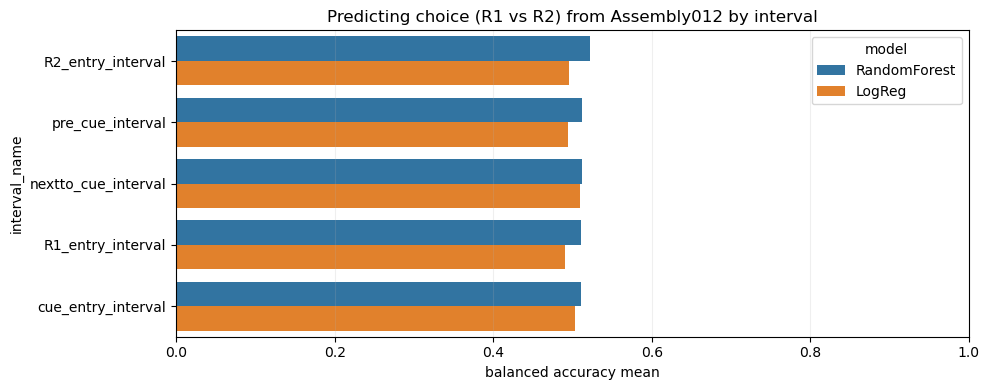

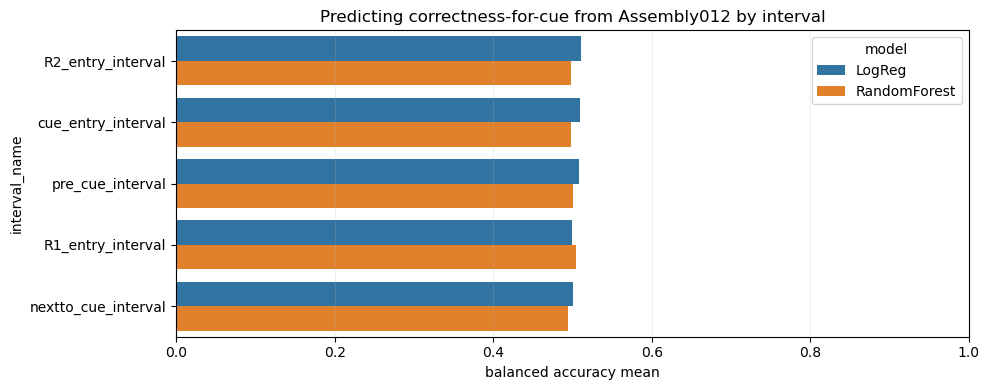

In [11]:
def plot_interval_metric(results_df, metric="balanced_accuracy_mean", title=None):
    if results_df.empty:
        print("No results to plot.")
        return

    plot_df = results_df.sort_values(metric, ascending=False).copy()
    plt.figure(figsize=(10, max(4, 0.45 * plot_df["interval_name"].nunique())))
    sns.barplot(
        data=plot_df,
        x=metric,
        y="interval_name",
        hue="model",
        orient="h",
    )
    plt.xlim(0, 1)
    plt.xlabel(metric.replace("_", " "))
    plt.ylabel("interval_name")
    plt.title(title or metric)
    plt.grid(axis="x", alpha=0.2)
    plt.tight_layout()


plot_interval_metric(
    choice_results,
    metric="balanced_accuracy_mean",
    title="Predicting choice (R1 vs R2) from Assembly012 by interval",
)

plot_interval_metric(
    correct_results,
    metric="balanced_accuracy_mean",
    title="Predicting correctness-for-cue from Assembly012 by interval",
)
